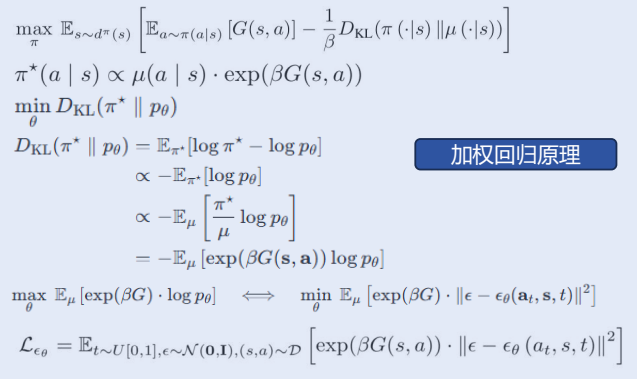

从最原始的**带 KL 散度约束的强化学习目标函数**出发，一步步推导到加权回归的闭式解（Analytic / Closed-form Solution）。

---

## 1. 优化目标的数学构建

在给定的状态 $s$ 下，我们的目标是找到一个新策略 $\pi(a|s)$，它不仅能最大化期望回报 $G(s,a)$，同时又不会偏离已有的行为策略（基准策略）$\mu(a|s)$ 太远。

我们在每个状态 $s$ 下单独求解这个优化问题：

$$\max_{\pi} \int_a \pi(a|s) G(s,a) \, da - \frac{1}{\beta} D_{\text{KL}}(\pi(\cdot|s) \parallel \mu(\cdot|s))$$

其中 $\beta$ 是一个正则化系数（倒数形式，控制约束的强度）。
展开 KL 散度公式 $D_{\text{KL}}(\pi \parallel \mu) = \int_a \pi(a|s) \log \frac{\pi(a|s)}{\mu(a|s)} \, da$，目标函数可以写为：

$$\max_{\pi} \int_a \pi(a|s) G(s,a) \, da - \frac{1}{\beta} \int_a \pi(a|s) \log \frac{\pi(a|s)}{\mu(a|s)} \, da$$

为了让形式更整洁，我们两边同乘 $\beta$：

$$\max_{\pi} \int_a \pi(a|s) \left[ \beta G(s,a) - \log \frac{\pi(a|s)}{\mu(a|s)} \right] da$$

由于 $\pi(a|s)$ 是一个概率分布，它必须满足**概率归一化约束**：


$$\int_a \pi(a|s) \, da = 1$$

---

## 2. 引入拉格朗日乘子法 (Lagrange Multipliers)

为了求解这个带约束的条件极值问题，我们构造拉格朗日函数 $\mathcal{L}(\pi, \lambda)$，引入乘子 $\lambda$：

$$\mathcal{L}(\pi, \lambda) = \int_a \pi(a|s) \left[ \beta G(s,a) - \log \pi(a|s) + \log \mu(a|s) \right] da + \lambda \left( \int_a \pi(a|s) \, da - 1 \right)$$

合并积分项：

$$\mathcal{L}(\pi, \lambda) = \int_a \left[ \pi(a|s) \left( \beta G(s,a) - \log \pi(a|s) + \log \mu(a|s) \right) + \lambda \pi(a|s) \right] da - \lambda$$

---

## 3. 变分求导 (Calculus of Variations)

接下来，我们需要对策略函数 $\pi(a|s)$ 的每一个动作概率值求变分（即对 $\pi(a|s)$ 求偏导），并令导数为 0：

$$\frac{\partial \mathcal{L}}{\partial \pi(a|s)} = 0$$

这里只对积分号内部的函数关于 $\pi(a|s)$ 求导：

* 第一项 $\pi(a|s) \cdot \beta G(s,a)$ 求导得：$\beta G(s,a)$
* 第二项 $-\pi(a|s) \log \pi(a|s)$ 利用乘积求导法则得：$-\log \pi(a|s) - \pi(a|s) \cdot \frac{1}{\pi(a|s)} = -\log \pi(a|s) - 1$
* 第三项 $\pi(a|s) \log \mu(a|s)$ 求导得：$\log \mu(a|s)$
* 第四项 $\lambda \pi(a|s)$ 求导得：$\lambda$

将这些项组合起来，令其等于 0：

$$\beta G(s,a) - \log \pi(a|s) - 1 + \log \mu(a|s) + \lambda = 0$$

---

## 4. 移项与指数化

现在我们把含有未知数 $\pi(a|s)$ 的项孤立到等式左边：

$$\log \pi(a|s) = \log \mu(a|s) + \beta G(s,a) + \lambda - 1$$

两边同时取指数（以 $e$ 为底）：

$$\pi(a|s) = \exp \left( \log \mu(a|s) + \beta G(s,a) + \lambda - 1 \right)$$

利用指数的性质 $\exp(A+B) = \exp(A)\exp(B)$ 展开：

$$\pi(a|s) = \exp(\log \mu(a|s)) \cdot \exp(\beta G(s,a)) \cdot \exp(\lambda - 1)$$

由于 $\exp(\log \mu(a|s)) = \mu(a|s)$，上式简化为：

$$\pi(a|s) = \mu(a|s) \cdot \exp(\beta G(s,a)) \cdot \exp(\lambda - 1)$$

---

## 5. 消除拉格朗日乘子（归一化）

注意，等式右侧的 $\exp(\lambda - 1)$ 是一个与具体动作 $a$ 无关的常数（只与状态 $s$ 有关）。我们可以把它定义为一个新的标量因子 $\frac{1}{Z(s)}$，其中 $Z(s)$ 是归一化常数（配分函数）：

$$\pi^*(a|s) = \frac{1}{Z(s)} \mu(a|s) \cdot \exp(\beta G(s,a))$$

为了满足 $\int_a \pi^*(a|s) \, da = 1$ 的约束，我们对两边积分：

$$Z(s) = \int_a \mu(a|s) \cdot \exp(\beta G(s,a)) \, da$$

在实际表达中，我们通常不需要显式计算出 $Z(s)$ 的精确值，而是使用正比例符号 $\propto$（Proportional to）来写：

$$\pi^*(a|s) \propto \mu(a|s) \cdot \exp(\beta G(s,a))$$

---

## 结论与直观理解

公式：


$$\pi^*(a|s) \propto \mu(a|s) \cdot \exp(\beta G(s,a))$$

**这个闭式解完美表达了离线强化学习的权衡：**

1. $\mu(a|s)$：保证新策略尊重历史数据集的分布（别去没探索过的区域作死）。
2. $\exp(\beta G(s,a))$：在这个安全的历史分布基础上，越能带来高回报 $G$ 的动作，其被选择的概率就以**指数级**放大。


得到了闭式解 $\pi^*(a|s) \propto \mu(a|s) \cdot \exp(\beta G(s,a))$ 之后，我们的目标是让一个参数化的策略网络 $\pi_\theta(a|s)$（例如一个神经网络、或扩散模型）去尽可能地逼近这个理想的 $\pi^*$。

在机器学习中，衡量两个概率分布 $\pi^*$ 和 $\pi_\theta$ 相似度最标准的方法就是 **KL 散度（Kullback-Leibler Divergence）**。

因此，转换到加权回归的推导过程，实际上就是**最小化 $D_{\text{KL}}(\pi^* \parallel \pi_\theta)$ 的过程**。下面是详细的数学推导：

---

### 1. 构建 KL 散度目标函数

我们希望通过调整网络参数 $\theta$，最小化 $\pi^*$ 与 $\pi_\theta$ 之间的 KL 散度：

$$\min_\theta D_{\text{KL}}(\pi^* \parallel \pi_\theta) = \min_\theta \mathbb{E}_{s \sim \mathcal{D}} \left[ \int_a \pi^*(a|s) \log \frac{\pi^*(a|s)}{\pi_\theta(a|s)} \, da \right]$$

利用对数的性质 $\log \frac{A}{B} = \log A - \log B$，展开积分项：

$$\int_a \pi^*(a|s) \log \frac{\pi^*(a|s)}{\pi_\theta(a|s)} \, da = \int_a \pi^*(a|s) \log \pi^*(a|s) \, da - \int_a \pi^*(a|s) \log \pi_\theta(a|s) \, da$$

注意：

* 第一项 $\int_a \pi^*(a|s) \log \pi^*(a|s) \, da$ 是理想策略 $\pi^*$ 的负熵，它里面**不包含我们需要优化的参数 $\theta$**。因此在求导优化时，这一项是常数，可以直接省去。
* 优化目标等价于最大化第二项（去掉负号）：

$$\max_\theta \mathbb{E}_{s \sim \mathcal{D}} \left[ \int_a \pi^*(a|s) \log \pi_\theta(a|s) \, da \right]$$

---

### 2. 代入闭式解

现在，我们将前面求得的闭式解 $\pi^*(a|s) = \frac{1}{Z(s)} \mu(a|s) \exp(\beta G(s,a))$ 代入到上述最大化目标中：

$$\max_\theta \mathbb{E}_{s \sim \mathcal{D}} \left[ \int_a \frac{1}{Z(s)} \mu(a|s) \exp(\beta G(s,a)) \log \pi_\theta(a|s) \, da \right]$$

这里有一个工程上的巧妙简化：归一化常数 $Z(s)$ 只与状态 $s$ 有关，与动作 $a$ 无关。在实际训练中，我们通常直接将 $Z(s)$ 视作常数省去（或者在离线数据集中通过批次归一化平衡），重点在于动作维度的加权。省去 $Z(s)$ 后目标变为：

$$\max_\theta \mathbb{E}_{s \sim \mathcal{D}} \left[ \int_a \mu(a|s) \exp(\beta G(s,a)) \log \pi_\theta(a|s) \, da \right]$$

---

### 3. 将积分转换为期望（利用历史数据集）

在离线强化学习（Offline RL）中，行为策略 $\mu(a|s)$ 就是**产生历史数据集 $\mathcal{D}$ 的基础分布**。
也就是说，从数据集中采样 $(s, a) \sim \mathcal{D}$，本质上就等价于先抽样状态 $s$，再根据行为策略抽样动作 $\int_a \mu(a|s) \dots da$。

利用这一性质，我们可以把复杂的动作积分 $\int_a \mu(a|s) \dots da$ 重新写回**对离线数据集的期望形式**：

$$\max_\theta \mathbb{E}_{(s,a) \sim \mathcal{D}} \left[ \exp(\beta G(s,a)) \log \pi_\theta(a|s) \right]$$

这就是图中左上角倒数第三行写到的：


$$\max_\theta \mathbb{E}_\mu [\exp(\beta G) \cdot \log p_\theta]$$

---

### 4. 转换成加权均方误差（加权回归 Loss）

最后一步取决于你的策略网络 $\pi_\theta(a|s)$ 是如何建模的：

#### 情况 A：如果是传统的高斯策略

假设我们的网络输出一个高斯分布的均值 $\mu_\theta(s)$，即 $\pi_\theta(a|s) \sim \mathcal{N}(\mu_\theta(s), \sigma^2 I)$。
那么它的对数似然为：


$$\log \pi_\theta(a|s) = -\frac{1}{2\sigma^2} \| a - \mu_\theta(s) \|^2 + \text{const}$$


代入最大化目标，忽略常数并把最大化变最小化，就得到了**加权均方误差（Weighted MSE）**：


$$\min_\theta \mathbb{E}_{(s,a) \sim \mathcal{D}} \left[ \exp(\beta G(s,a)) \cdot \| a - \mu_\theta(s) \|^2 \right]$$

#### 情况 B：如果是扩散策略（Diffusion Policy，如图中所示）

扩散模型不直接输出单步动作，而是通过多步去噪来预测噪声 $\epsilon$ 或轨迹。在 $t$ 时刻，对数似然 $\log p_\theta$ 对应于噪声预测的负均方误差。  
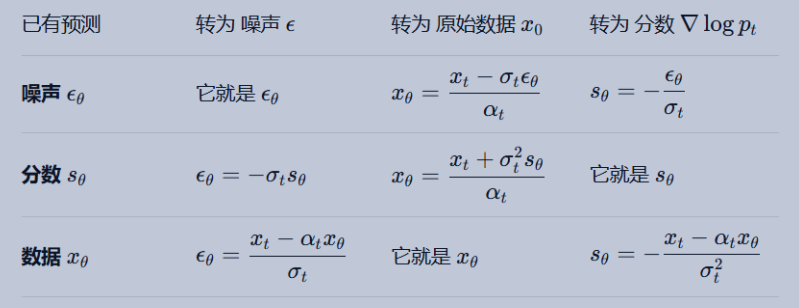  
因此，将 $\log p_\theta$ 替换为扩散模型的标准优化项 $\| \epsilon - \epsilon_\theta \|^2$，就得到了最终损失函数：

$$\mathcal{L}_{\epsilon_\theta} = \mathbb{E}_{t \sim U[0,1], \epsilon \sim \mathcal{N}(0, \mathbf{I}), (s,a) \sim \mathcal{D}} \left[ \exp(\beta G(s,a)) \cdot \| \epsilon - \epsilon_\theta(a_t, s, t) \|^2 \right]$$

---

### 总结：它是怎么“回归”的？

传统的行为克隆（Behavior Cloning, BC）是无差别地模仿数据集里的所有动作，Loss 是 $\|a - \pi_\theta(s)\|^2$。

而通过这一套推导，我们在普通的 BC 损失函数前面乘上了一个权重系数 **$\exp(\beta G(s,a))$**：

* 如果历史数据中某个动作带来的回报 $G$ 很高，权重 $\exp(\beta G)$ 就会很大，Loss 就会逼迫网络**用力去拟合和模仿**这个动作。
* 如果某个动作的回报 $G$ 很低（比如撞墙），权重接近于 0，网络就会**选择性忽略**这个错误示范。

通过这种“选择性模仿”的加权回归，生成模型就能在不进行任何在线试错的情况下，直接从离线数据里筛选并学会最优策略。

我们可以将前面关于加权回归（Weighted Regression）的深度讨论，梳理为一个逻辑闭环。

这一套从强化学习目标函数演进到离线生成策略的工程逻辑，其核心可以总结为“理论上是在线信赖域，工程上是离线选择性克隆”。

---

## 1. 理论根基：带约束的策略最大化

加权回归与 PPO、TRPO 等经典强化学习算法同宗同源，它们最核心的数学出发点完全一致：**在不偏离行为（旧）策略 $\mu$ 的安全范围（KL散度约束）内，最大化期望回报 $G(s,a)$**。

通过拉格朗日乘子法和变分求导，该受限优化问题可以推导出极其优雅的**闭式解（解析解）**：


$$\pi^*(a|s) \propto \mu(a|s) \cdot \exp(\beta G(s,a))$$

> **核心结论**：该最优解不是全局最优，而是当前策略可控邻域（信赖域）内的局部最优解。

---

## 2. 演进分叉：PPO（在线） vs 加权回归（离线）

为了在工程中求解并逼近这个理论最优解，RL 演进出了两条完全不同的路径：

* **PPO 选择了“在线（Online）”路径**：PPO 放弃了直接拟合闭式解，而是采用**重要性采样**来修正新旧策略的分布偏差，并通过硬剪切（Clip）维持信赖域。这使得它能利用同一批在线采集的数据连续更新数次梯度，但缺点是极难适配多步去噪的扩散模型。
* **加权回归选择了“离线（Offline）”路径**：加权回归通过“积分变期望”的数学转换，完美将分布 $\mu$ 绑定为了**静态的历史数据集 $\mathcal{D}$**。它通过单次或有限次的监督回归来逼近闭式解，彻底免去了在线交互的昂贵成本。

---

## 3. 落地真相：Offline + Off-policy 的行为克隆

在自动驾驶或机器人控制的实际落地中，这套算法发生了一种极其绝妙的“退化”与升级：

* **退化**：算法退化为了纯粹的 **Offline + Off-policy** 模仿学习。行为策略 $\mu$ 不再是动态更新的旧策略，而是**死死固定在硬盘里的、由人类驾驶员产生的静态专家数据集**。
* **升级（相比普通 BC）**：普通的行为克隆（Behavior Cloning）是在盲目模仿数据集里的所有行为。而加权回归利用权重系数 $\exp(\beta G(s,a))$ 实现了**选择性克隆**——它充当了过滤器，只让网络“拼命模仿”高回报的完美轨迹，而“选择性忽略”那些低回报的瑕疵数据。


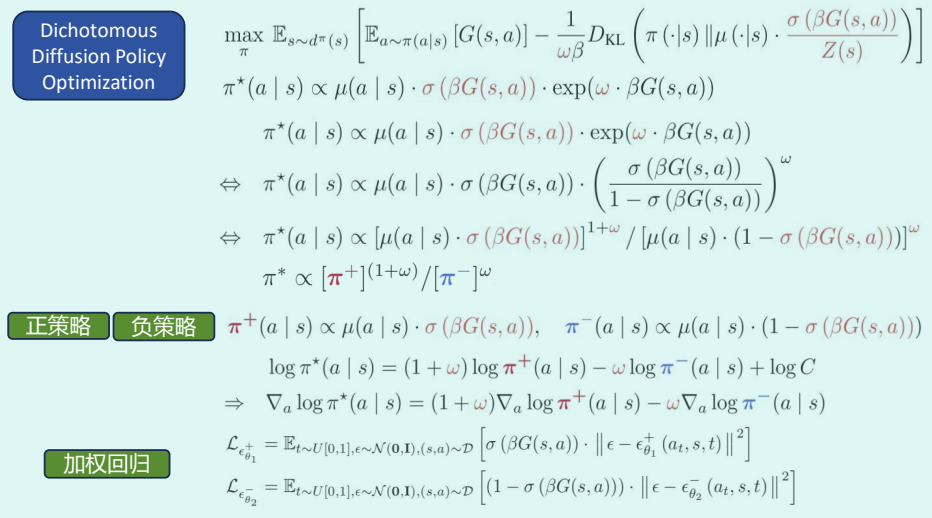

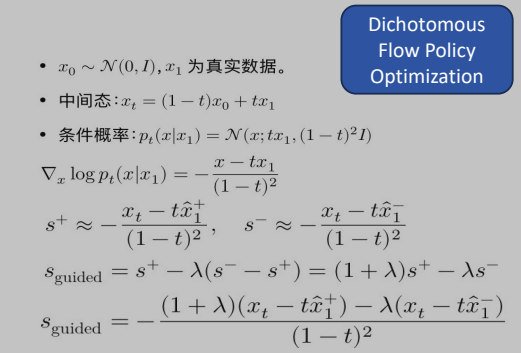  
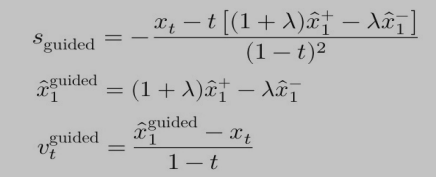
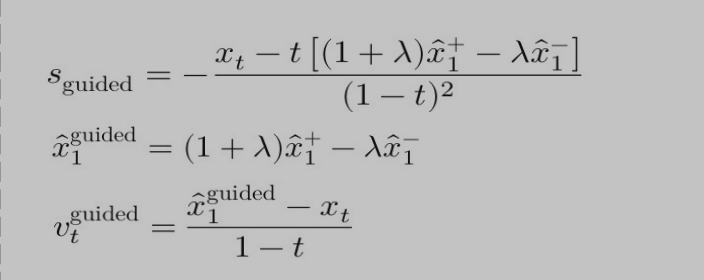
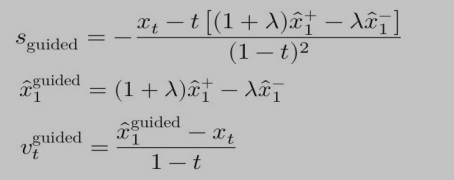

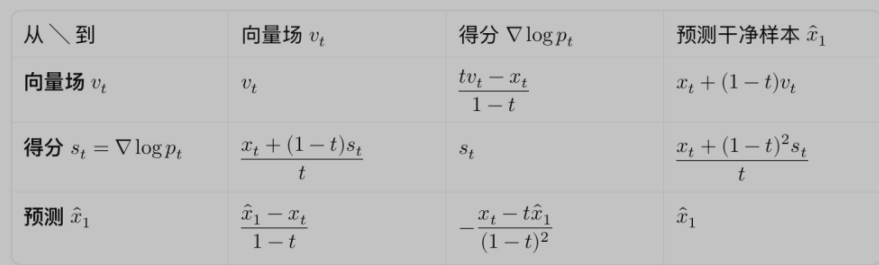

### 以下是针对 **DIPOLE（双分扩散/流策略优化，Dichotomous Diffusion/Flow Policy Optimization）** 算法的完整系统性整理。内容涵盖算法概述、核心动机、显著优势以及严谨的数学推推导。

---

## 一、 DIPOLE 算法概述

**DIPOLE** 是一种专为离线强化学习（Offline RL）与具身智能（如自动驾驶轨迹规划、机器人操作）设计的**生成式策略优化算法**。

它完美地将受限策略优化（Constrained Policy Optimization）**的数学严谨性与**条件生成模型（Diffusion Models / Flow Matching）强大的多峰分布拟合能力相结合。通过在训练期将数据集解耦为正、负两路独立加权回归，并在推理期进行流场/得分空间的对立几何拉扯，实现了“追求极致专家表现”与“绝对远离边界红线”的统一。

---

## 二、 核心动机（Motivation）

在离线自动驾驶等实际场景中，现有的离线生成式策略（如 Diffusion Policy）在落地时面临两个核心痛点：

1. **对负面示例（Negative Demonstration）的利用率极低**：
离线数据集中不仅包含完美的专家轨迹，往往还夹杂着大量“差一点碰撞”、“急刹车”或“违章”的边界负面样本。传统的加权回归（如 AWR, AWAC）仅仅是通过赋予这些样本极低的权重来**忽略**它们。然而，在安全要求极高的场景中，**“明确知道什么是危险”和“知道什么是正确”同等重要**。
2. **多峰分布下的均值模糊（Mean-Blurring）与泛化崩溃**：
传统的决策模型（如高斯策略）在面对“左转”或“右转”都合理的抉择时，输出会坍缩到中间的危险区域。即使引入了 Diffusion 模型，如果不能显式地在未探索区域边界建立“排斥壁垒”，模型在长尾测试场景（Corner Cases）中仍可能泛化出诡异的失效轨迹。

---

## 三、 算法优势（Advantages）

* **训练期完全解耦，零相互干扰**：正策略与负策略使用完全独立的网络分头训练，避免了传统 Actor-Critic 算法中多目标优化（如同时最大化回报与最小化碰撞风险）带来的梯度抵消与不稳定。
* **极致利用长尾负样本（红线机制）**：负策略显式地对失败行为进行行为克隆，在决策空间中精准画出“危险红线”，极大地提升了系统在未见过的危险场景中的避障泛化能力。
* **推理期风格可动态调节**：合并正负策略的超参数 $\lambda$（Guidance Scale）是在推理期直接生效的。这意味着无需重新训练模型，只需调整 $\lambda$，就能让车辆在“激进的高效驾驶”与“保守的安全驾驶”风格之间无缝切换。
* **流匹配（Flow Matching）算子完美对齐**：DIPOLE 能够天生适配连续时间流匹配，直接在物理意义明确的速度场（Velocity Field）上做对立拉扯，规避了传统扩散模型在 $t \to 1$ 边界时因分母接近 0 导致的数值爆炸问题。

---

## 四、 严谨数学推导闭环

### 1. 构建双分偏好目标函数

为了在数学上显式引入对低回报（危险）行为的非线性惩罚，DIPOLE 巧妙地将包含 Sigmoid 偏好权重的项作为参考测度（Reference Measure）塞进了 KL 散度内部：

$$\max_{\pi} \mathbb{E}_{s \sim d^\mu(s)} \left[ \mathbb{E}_{a \sim \pi(a|s)} [G(s,a)] - \frac{1}{\omega\beta} D_{\text{KL}}\left(\pi(\cdot|s) \;\Big\|\; \mu(\cdot|s) \cdot \frac{\sigma(\beta G(s,a))}{Z(s)}\right) \right]$$

其中，$\mu(a|s)$ 为数据集的历史行为策略，$\sigma(x) = \frac{1}{1+e^{-x}}$ 为 Sigmoid 函数，$Z(s)$ 为配分函数。

为简化推导，将目标整体乘以正常数 $\omega\beta>0$，得到等价问题：

$$
\max_\pi \omega\beta\,\mathbb{E}_{a\sim\pi}[G] - D_{\text{KL}}\!\left(\pi \,\Big\|\, \mu\cdot\frac{\sigma}{Z}\right)
$$


固定状态 $s$，将 KL 散度按照定义展开：

$$\max_{\pi} \int_a \pi(a|s) \left[ \omega\beta G(s,a) - \log \pi(a|s) + \log \mu(a|s) + \log \sigma(\beta G(s,a)) - \log Z(s) \right] da$$

### 2. 变分求解闭式解（Closed-form Solution）

引入拉格朗日乘子 $\lambda_0$ 维持约束 $\int_a \pi(a|s) \, da = 1$，构造拉格朗日函数：

$$\mathcal{L}(\pi, \lambda_0) = \int_a \pi(a|s) \left[ \omega\beta G(s,a) - \log \pi(a|s) + \log \mu(a|s) + \log \sigma(\beta G(s,a)) - \log Z(s) \right] da + \lambda_0 \left( \int_a \pi(a|s) \, da - 1 \right)$$

对 $\pi(a|s)$ 求变分导数并令其等于 0：

$$\frac{\partial \mathcal{L}}{\partial \pi(a|s)} = \omega\beta G(s,a) - \log \pi(a|s) - 1 + \log \mu(a|s) + \log \sigma(\beta G(s,a)) - \log Z(s) + \lambda_0 = 0$$

孤立 $\log \pi(a|s)$ 并两边取指数，由于 $\exp(\lambda_0 - 1 - \log Z(s))$ 与动作 $a$ 无关，归入正比例常数：

$$\pi^*(a|s) \propto \mu(a|s) \cdot \sigma(\beta G(s,a)) \cdot \exp(\omega \cdot \beta G(s,a))$$

### 3. 双分对立分解（Dichotomous Decomposition）

利用 Sigmoid 的代数性质 $\exp(x) = \frac{\sigma(x)}{1-\sigma(x)}$，改写线性回报项：

$$\pi^*(a|s) \propto \mu(a|s) \cdot \sigma(\beta G(s,a)) \cdot \left( \frac{\sigma(\beta G(s,a))}{1 - \sigma(\beta G(s,a))} \right)^\omega = \mu(a|s) \cdot \frac{\big(\sigma(\beta G(s,a))\big)^{1+\omega}}{\big(1 - \sigma(\beta G(s,a))\big)^\omega}$$

此时进行最核心的代数变换：在分子、分母上同时强行乘以行为策略的幂次 $\mu(a|s)^\omega$：

$$\pi^*(a|s) \propto \frac{\mu(a|s) \cdot \mu(a|s)^\omega \cdot \big(\sigma(\beta G(s,a))\big)^{1+\omega}}{\mu(a|s)^\omega \cdot \big(1 - \sigma(\beta G(s,a))\big)^\omega} = \frac{\big[ \mu(a|s) \cdot \sigma(\beta G(s,a)) \big]^{1+\omega}}{\big[ \mu(a|s) \cdot (1 - \sigma(\beta G(s,a))) \big]^\omega}$$

显式定义两个完全解耦的正、负基准策略分布：

* **正策略（专家）**：$\pi^+(a|s) \propto \mu(a|s) \cdot \sigma(\beta G(s,a))$
* **负策略（边界）**：$\pi^-(a|s) \propto \mu(a|s) \cdot (1 - \sigma(\beta G(s,a)))$

代入上式，直接退化出最终的**对立策略商形式**：

$$\pi^*(a|s) \propto \frac{[\pi^+(a|s)]^{(1+\omega)}}{[\pi^-(a|s)]^\omega}$$

### 4. 转换到离线扩散加权回归（Training Phase）

在训练期，由于数据集是静态的，我们直接利用 $\sigma(\beta G)$ 和 $1-\sigma(\beta G)$ 对样本进行加权，从而将复杂的策略求解变成两路完全独立的 **Offline + Off-policy 监督均方误差回归**：

$$\mathcal{L}_{\epsilon_{\theta_1}}^+ = \mathbb{E}_{t, \epsilon, s, a} \left[ \sigma(\beta G(s,a)) \cdot \|\epsilon - \epsilon_{\theta_1}^+(a_t, s, t)\|^2 \right]$$

$$\mathcal{L}_{\epsilon_{\theta_2}}^- = \mathbb{E}_{t, \epsilon, s, a} \left[ (1 - \sigma(\beta G(s,a))) \cdot \|\epsilon - \epsilon_{\theta_2}^-(a_t, s, t)\|^2 \right]$$

### 5. 映射到连续时间流匹配控制（Inference Phase）

在测试期，对对立商公式两边取 Log 并关于 $a$ 提取梯度，令外推调节系数 $\lambda = \omega$：

$$\nabla_a \log \pi^*(a|s) = (1+\lambda)\nabla_a \log \pi^+(a|s) - \lambda\nabla_a \log \pi^-(a|s) \implies s_{\text{guided}} = (1+\lambda)s^+ - \lambda s^-$$

在流匹配（Flow Matching）框架中，定义状态插值路径为 $x_t = (1-t)x_0 + t x_1$（$x_1$ 为轨迹真值）。已知条件得分映射为 $s_t = -\frac{x_t - t \hat{x}_1}{(1-t)^2}$。

将正、负策略的预测得分代入，可以直接合并解出干净目标（真值空间）的外推公式：

$$\hat{x}_1^{\text{guided}} = (1+\lambda)\hat{x}_1^+ - \lambda\hat{x}_1^-$$

最后，利用流匹配变换矩阵 $v = \frac{\hat{x}_1 - x_t}{1-t}$，转换为直接驱动 ODE 积分器的**最优速度场（Velocity Field）**：

$$v_t^{\text{guided}} = (1+\lambda) v_t^+ - \lambda v_t^-$$

这一公式在几何上展现了无与伦比的直观性：车辆最终的控制速度，是朝着安全专家速度 $v_t^+$ 加速推进的同时，狠狠地一脚踹开危险边界速度 $v_t^-$。

## **“DIPOLE 为什么要这样设计目标函数”** 以及 **“它与传统加权回归的根本不同”**。

---

## 一、传统加权回归在做什么，以及它的软肋

传统加权回归（如 AWR、AWAC 的底层）基于以下目标：

$$
\max_\pi\; \mathbb{E}_{s\sim d^\mu}\!\left[ \mathbb{E}_{a\sim\pi}[G] - \frac{1}{\beta} D_{\text{KL}}(\pi \| \mu) \right]
$$

它的闭式最优解是：

$$
\pi^* \propto \mu \cdot e^{\beta G}
$$

训练时，等价于用权重 $e^{\beta G}$ 做加权 MSE。这套框架有两个致命的代数缺陷：

| 缺陷 | 后果 |
|------|------|
| **1. 权重无界** | 回报极高时 $e^{\beta G} \to \infty$，长尾噪声样本会劫持梯度；回报极低时 $e^{\beta G} \to 0$，模型直接忽视危险样本。 |
| **2. 锚点太低** | KL 约束的参考测度是原始行为策略 $\mu$——一个混杂了好坏动作的“脏水池”。新策略被强行拴在脏数据附近，无法形成清晰的“远离危险”的力。 |

由此，加权回归只能做到 **“单向筛选”**：用好样本，丢掉坏样本，但永远学不会主动排斥坏样本。

---

## 二、DIPOLE 的目标函数是怎么改造的

DIPOLE 的目标是：

$$
\max_\pi\; \mathbb{E}_s\!\left[ \mathbb{E}_{a\sim\pi}[G] - \frac{1}{\omega\beta} D_{\text{KL}}\!\left( \pi \Big\| \mu \cdot \frac{\sigma(\beta G)}{Z(s)} \right) \right]
$$

注意这里的 KL 参考测度不再是 $\mu$，而是 **$\mu$ 被回报过滤后的加权分布** $\mu \cdot \sigma(\beta G)/Z$。

这带来了两个质变。

---

## 三、为什么要用 Sigmoid 替代指数

把 $e^{\beta G}$ 换成 $\sigma(\beta G)$，是两个层面的升级：

1. **有界性**  
   $\sigma \in (0,1)$ 天然有界。高回报样本的权重饱和在 1，低回报样本的权重稳稳压在 0。不会爆炸，也不会彻底归零。

2. **从“放大倍数”变成“选择概率”**  
   $\sigma$ 可以被理解为“这个动作属于正向样本的概率”。正是一旦变成了概率，才天然地产生了它的对偶概率 $1-\sigma$，为后续把数据集拆成正、负两个子分布铺平了道路。指数函数永远做不到这一点，因为 $1-e^x$ 不是一个合法的概率。

---

## 四、为什么必须把加权项塞进 KL 内部

这是最“怪”却最精妙的一步。如果把 Sigmoid 当成外部奖励塑形，写成：

$$
\mathbb{E}[G \cdot \sigma] - \frac{1}{\beta} D_{\text{KL}}(\pi \| \mu)
$$

则求导后策略与 Sigmoid 死死纠缠，无法拆成两个独立网络。

只有把它放进 KL 的参考测度里，变分最优解才会是：

$$
\pi^* \propto \mu \cdot \sigma(\beta G) \cdot e^{\omega\beta G}
$$

进一步利用恒等式 $e^{\omega\beta G} = \left(\frac{\sigma}{1-\sigma}\right)^\omega$（当 $G$ 被定义满足 $\sigma$ 与 $G$ 的单调关系时成立），这个解就可以被干净地写成正、负策略的商：

$$
\pi^* \propto \frac{ \big(\mu \cdot \sigma\big)^{1+\omega} }{ \big(\mu \cdot (1-\sigma)\big)^\omega }
= \frac{ (\pi^+)^{1+\omega} }{ (\pi^-)^\omega }
$$

其中：

$$
\pi^+ \propto \mu \cdot \sigma,\qquad \pi^- \propto \mu \cdot (1-\sigma)
$$

这两个分布分别是“高回报区域的加权策略”和“低回报区域的加权策略”。它们对应两个独立的扩散网络，可以分开训练。代数上这种解耦，只有在参考测度内部包含 $\sigma$ 时才会发生。

---

## 五、这一设计在物理上意味着什么

关键差别落在 **KL 约束锚点的质变** 上：

- **传统加权回归**：约束锚点是 $\mu$（全量数据分布）。策略被一条橡皮筋拴在脏水池中央。
- **DIPOLE**：约束锚点是 $\mu \cdot \sigma(\beta G)/Z$。由定义可知，这个锚点恰好就是 **加权回归得到的最优正策略 $\pi^+$**。换句话说，DIPOLE 的 KL 惩罚是说：“你不要离正策略太远”，而不是“不要离原始数据太远”。

此时，外层的 $\mathbb{E}[G]$ 还在把策略往更高回报的方向拉，而 KL 橡皮筋的另一端已经是一个已经过滤好的专家分布。两者拉扯的结果，就是在正策略 $\pi^+$ 的基础上，再外推一个由 $\omega$ 控制的步长，并且同时推开负策略 $\pi^-$。最终在推理时，就表现为那个明确的 **“正吸引，负排斥”** 的引导场：

$$
\nabla_a \log \pi^* = (1+\omega)\nabla_a \log \pi^+ - \omega\nabla_a \log \pi^- + \text{const}
$$

---

## 六、DIPOLE vs. 传统加权回归 对照表

| 维度 | 传统加权回归 | DIPOLE |
|------|------------|--------|
| **权重函数** | $e^{\beta G}$（无界） | $\sigma(\beta G)$（有界，概率化） |
| **对坏样本的态度** | 权重 → 0，忽略 | 权重 → $1-\sigma$，专门学习，推理时推开 |
| **KL 参考测度** | 原始行为策略 $\mu$ | 回报过滤后的专家分布 $\pi^+$ |
| **策略最优解** | $\mu \cdot e^{\beta G}$ | $\frac{(\pi^+)^{1+\omega}}{(\pi^-)^\omega}$（正负解耦） |
| **网络结构** | 单一网络 | 正、负两个独立网络 |
| **推理机制** | 沿着一个得分方向走 | 两个场对抗：$v^{\text{guided}} = (1+\lambda)v^+ - \lambda v^-$ |
| **本质** | 单向过滤筛选 | 双向对比对齐 |

---

## 七、总结

DIPOLE 目标函数设计的全部精义，可以浓缩成一句话：

> 用有界的 Sigmoid 将权重概率化，再通过把该概率测度塞进 KL 内部，将约束锚点从“脏数据池”质变为“加权最优专家”，从而在代数上实现了正、负策略的彻底解耦，并在推理时产生一套清晰的“正吸引、负排斥”力场。

它不再像传统加权回归那样“只跟好人玩”，而是同时 **铭记好人与坏人，并沿着好坏分界线向外安全外推**。这就是你对它的定位：从“单向过滤”到“双向对比对齐”的降维打击。